In [12]:
import pandas as pd

# Load original dataset
data = pd.read_csv("creditcard.csv")

# Select only required columns
data = data[['V1','V2','V3','V4','V5','V6','V7','V8','V9','Amount','Time','Class']]

# Save filtered dataset
data.to_csv("fraud_filtered.csv", index=False)

print("Dataset prepared successfully!")



Dataset prepared successfully!


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [14]:

data = pd.read_csv("fraud_filtered.csv")
data.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,Amount,Time,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,149.62,0.0,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,2.69,0.0,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,378.66,1.0,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,123.50,1.0,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,69.99,2.0,0


In [15]:
data.info()
data['Class'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 12 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   V1      284807 non-null  float64
 1   V2      284807 non-null  float64
 2   V3      284807 non-null  float64
 3   V4      284807 non-null  float64
 4   V5      284807 non-null  float64
 5   V6      284807 non-null  float64
 6   V7      284807 non-null  float64
 7   V8      284807 non-null  float64
 8   V9      284807 non-null  float64
 9   Amount  284807 non-null  float64
 10  Time    284807 non-null  float64
 11  Class   284807 non-null  int64  
dtypes: float64(11), int64(1)
memory usage: 26.1 MB


Class
0    284315
1       492
Name: count, dtype: int64

In [16]:
X = data.drop('Class', axis=1)
y = data['Class']

In [17]:
scaler = StandardScaler()
data['Amount'] = scaler.fit_transform(data[['Amount']])

In [18]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
model = LogisticRegression(max_iter=2000,class_weight='balanced')
model.fit(X_train, y_train)

/Users/godson/Desktop/machine learning/name_of_my_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/godson/Desktop/machine learning/name_of_my_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/godson/Desktop/machine learning/name_of_my_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/godson/Desktop/machine learning/name_of_my_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/godson/Desktop/machine learning/name_of_my_env/lib/python3.9/site-packages/sklearn/linear_mo

LogisticRegression(class_weight='balanced', max_iter=2000)

In [21]:
y_pred = model.predict(X_test)
rf_pred = rf.predict(X_test)

/Users/godson/Desktop/machine learning/name_of_my_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/godson/Desktop/machine learning/name_of_my_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/godson/Desktop/machine learning/name_of_my_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [22]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Logistic Accuracy:", accuracy_score(y_test, y_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Logistic Accuracy: 0.9539693128752502
Random Forest Accuracy: 0.9990695551420246


In [23]:
print("Logistic Accuracy:", accuracy_score(y_test, y_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Logistic Accuracy: 0.9539693128752502
Random Forest Accuracy: 0.9990695551420246

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.95      0.98     56864
           1       0.03      0.91      0.06        98

    accuracy                           0.95     56962
   macro avg       0.52      0.93      0.52     56962
weighted avg       1.00      0.95      0.97     56962


Confusion Matrix:

[[54251  2613]
 [    9    89]]


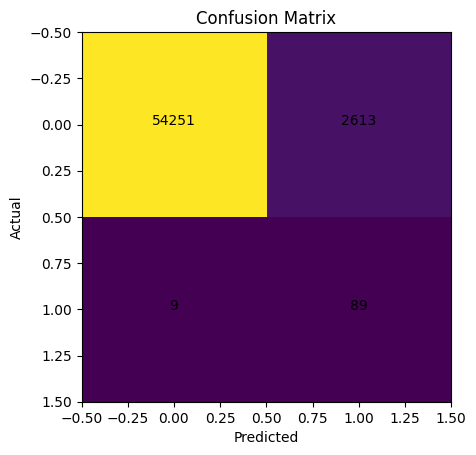

In [24]:
cm = confusion_matrix(y_test, y_pred)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha='center')

plt.show()

In [25]:
# Example input (you can change values)
sample = np.array([[ 
    0.1, -1.2, 0.5, 0.3, -0.6, 1.2, -0.7, 0.8, 0.2,  # V1–V9
    500,   # Amount
    10     # Time
]])

# Scale amount
sample[0][9] = scaler.transform([[sample[0][9]]])[0][0]

# Prediction
prediction = model.predict(sample)[0]

if prediction == 1:
    print("⚠️ Fraud Detected")
else:
    print("✅ Legitimate Transaction")

✅ Legitimate Transaction


/Users/godson/Desktop/machine learning/name_of_my_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/godson/Desktop/machine learning/name_of_my_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [26]:
# FRAUD-LIKE INPUT
sample = np.array([[ 
    -2.5, 3.2, -1.8, 2.5, -3.0, 1.5, -2.2, 2.8, -1.9,  # V1–V9
    8000,   # High Amount (important)
    1       # Very early time (suspicious)
]])

# Scale amount
sample[0][9] = scaler.transform([[sample[0][9]]])[0][0]

# Prediction
prediction = model.predict(sample)[0]

if prediction == 1:
    print("⚠️ Fraud Detected")
else:
    print("✅ Legitimate Transaction")

⚠️ Fraud Detected


/Users/godson/Desktop/machine learning/name_of_my_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/godson/Desktop/machine learning/name_of_my_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [27]:
sample = np.array([[
    -5.0, 4.5, -3.2, 3.8, -4.1, 2.5, -3.7, 4.2, -2.9,  # V1–V9
    12000,   # Amount
    0    ]])

sample[0][9] = scaler.transform([[sample[0][9]]])[0][0]

prob = model.predict_proba(sample)[0][1]

print("Fraud Probability:", prob)

if prob > 0.3:
    print("⚠️ Fraud Detected")
else:
    print("✅ Legitimate")

Fraud Probability: 0.9890095763433765
⚠️ Fraud Detected


/Users/godson/Desktop/machine learning/name_of_my_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/godson/Desktop/machine learning/name_of_my_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
